## Spatial Mouse Placentation Quick Run

1. This notebook provides a compact, end-to-end workflow for Spatial Mouse Placentation based on the main STEER quickstart pipeline. The current settings match the configuration used for the main figure. We set `training_mode="full"` to leverage the full capacity of the model. The complete run may take about 2 hours on a single NVIDIA L20 GPU (with approximately 40 GB of GPU memory).

2. If GPU memory is limited, `velo_batch_size` is the key parameter for reducing memory usage. During kinetics training, it randomly samples batches of cells. Empirically, a velocity loss below 0.1 usually indicates that the model has trained well.

All main-figure results associated with this project are available on Zenodo: `10.5281/zenodo.18713189`.

## Input

The recommended input is an `AnnData` object containing `spliced`, `unspliced`, and spatial coordinates. If the file only provides `obsm['spatial']`, the preparation step below will standardize it to `X_spatial` automatically.


In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import seaborn as sns
import torch
import torch.backends.cudnn as cudnn

import steer
from steer.prior.prior import PriorInferenceManager

warnings.filterwarnings("ignore")
%matplotlib inline

print("=== STEER Quick Start Environment ===")
print(f"PyTorch version: {torch.__version__}")
print(f"Scanpy version: {sc.__version__}")
print(f"scVelo version: {scv.__version__}")
print(f"STEER version: {getattr(steer, '__version__', 'dev build')}")
print("====================================")

=== STEER Quick Start Environment ===
PyTorch version: 2.8.0+cu128
Scanpy version: 1.10.2
scVelo version: 0.3.3
STEER version: 2.2.2


## Config

1. This section includes only the settings that users are most likely to modify. The current default setup uses `training_mode="full"`, which matches the configuration used to generate the results shown in this notebook.

- `"full"`: uses the default STEER training arguments without overrides and runs the complete training schedule.
- `"fast"`: uses a lightweight, quickstart-style parameter set for faster demos and iteration.

- For advanced usage, you can further customize the `"fast"` setting in `get_stage1_training_overrides` and `get_stage2_training_overrides`. For example, you may remove the `epochs` and `patience` settings to fall back to the same defaults as `"full"` mode, while still adjusting `velo_batch_size` to reduce GPU memory usage. This can provide more thorough training than the default `"fast"` mode while requiring less GPU memory than `"full"` mode.

2. Only the most important settings are exposed here:

- `data_name` / `input_dir` / `result_dir`: control input and output locations

- For a first run on a new dataset, it is usually enough to update the data path and `training_mode`.


In [2]:
class Config:
    # Data
    data_name = "E8.5_S1.MPSTA"
    input_dir = "/nvme/users/liuzhy/Review_Files/6_Stereoseq_MousePlacentation"
    result_dir = "./results"
    seed = 618

    # Core model and graph settings
    expert = 10  # Number of experts. You can adjust this based on biological prior knowledge
                 # or an estimated cluster number (see quickstart.ipynb).
    smooth_neigh = 50  # Number of neighbors used for smoothing.
                       # Usually 50-100 works well; increase for noisier data.
    spatial_neighbors = 8  # Number of spatial neighbors. We recommend keeping this below 30.
    
    # Training profile
    training_mode = "full"  # Choose from "full" or "fast".
    # finetune_epochs = 5000  # Only used when training_mode == "fast".

    # Advanced settings
    graph = "union"  # Combine expression and spatial graphs to define cellular context.
    corr_mode = "u"  # Use unspliced counts for temporal supervision.
                     # If time inference is unsatisfactory and unspliced counts are low,
                     # try setting this to "s" and rerun.
    neighbor_metric = "cosine"  # Neighbor metric. You can also use Euclidean distance.
    use_us = True  # Use both unspliced and spliced counts as input features.
    use_filter = True  # Filter genes before kinetics learning to keep informative genes.

    # Time constraint
    # Default setting: constrain time inference within each expert.
    fine_method = "none"
    target_size = 300
    direction_base = "expert"

    # Optional setting for fewer experts (<5):
    # use a more flexible constraint based on fine-grained clusters.
    # fine_method = "hierarchical"
    # target_size = 300
    # direction_base = "fine_cluster"

cfg = Config()

INPUT_FILE = os.path.join(cfg.input_dir, f"{cfg.data_name}.h5ad")
RESULT_PATH = os.path.join(cfg.result_dir, f"{cfg.data_name}_quickstart")
os.makedirs(RESULT_PATH, exist_ok=True)


def get_stage1_training_overrides(mode: str) -> dict:
    if mode == "full":
        return {}
    if mode == "fast":
        return {
            "expert_mode": "slim",
            "pretrain_epochs": 500,
            "cluster_epochs": 200,
        }
    raise ValueError(f"Unsupported training_mode: {mode}")


def get_stage2_training_overrides(mode: str, finetune_epochs=None) -> dict:
    if mode == "full":
        return {}
    if mode == "fast":
        if finetune_epochs is None:
            raise ValueError("cfg.finetune_epochs must be set when training_mode='fast'.")
        return {
            "expert_mode": "slim",
            "pretrain_epochs": 500,
            "cluster_epochs": 200,
            "velo_batch_size": 512,
            "MIN_IMPRO": 0.01,
            "PATIENCE": 100,
            "num_epochs": finetune_epochs,
        }
    raise ValueError(f"Unsupported training_mode: {mode}")


print(f"Input file: {INPUT_FILE}")
print(f"Output directory: {RESULT_PATH}")
print(f"Training mode: {cfg.training_mode}")


Input file: /nvme/users/liuzhy/Review_Files/6_Stereoseq_MousePlacentation/E8.5_S1.MPSTA.h5ad
Output directory: ./results/E8.5_S1.MPSTA_quickstart
Training mode: full


## Seed And Device

This cell fixes the random seed for reproducibility and automatically selects GPU or CPU.


In [3]:
def setup_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.deterministic = True
    cudnn.benchmark = False

setup_seed(cfg.seed)
# you need to use your device number
if torch.cuda.is_available():
    device = torch.device("cuda:0")
print(f"Using device: {device}")

Using device: cuda:2


## Load Data

Load the `.h5ad` file and check that the required layers and spatial coordinates are present. When users switch to their own data, this is usually the first place where formatting issues appear.


In [4]:
adata = sc.read_h5ad(INPUT_FILE)
adata = steer.prepare_spatial_adata(
    adata,
    obs_copy_map={"celltype": "celltype1"},
    na_clear_keys=["subregion"],
    celltype_key="celltype",
    remove_celltypes=[],
)

print(adata)
print("\nAvailable layers:", list(adata.layers.keys()))
print("Available obsm keys:", list(adata.obsm.keys()))
print(f"Number of cells: {adata.n_obs}")
print(f"Number of genes: {adata.n_vars}")

required_layers = ["spliced", "unspliced"]
missing_layers = [layer for layer in required_layers if layer not in adata.layers]
if missing_layers:
    raise ValueError(f"Missing required layers: {missing_layers}")
if "X_spatial" not in adata.obsm:
    raise ValueError("Spatial coordinates were not standardized into adata.obsm['X_spatial'].")


AnnData object with n_obs × n_vars = 13258 × 17646
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subregion', 'interface', 'celltype1', 'subclusters_5_last', 'subregion5', 'celltype'
    var: 'n_cells_by_counts'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_spatial'
    layers: 'ambiguous', 'counts', 'matrix', 'spliced', 'unspliced'

Available layers: ['ambiguous', 'counts', 'matrix', 'spliced', 'unspliced']
Available obsm keys: ['X_pca', 'X_umap', 'spatial', 'X_spatial']
Number of cells: 13258
Number of genes: 17646


In [5]:
adata

AnnData object with n_obs × n_vars = 13258 × 17646
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subregion', 'interface', 'celltype1', 'subclusters_5_last', 'subregion5', 'celltype'
    var: 'n_cells_by_counts'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_spatial'
    layers: 'ambiguous', 'counts', 'matrix', 'spliced', 'unspliced'

## Preprocess

Run the basic normalization step and build the dataframe, adjacency matrix, and processed `AnnData` object required by STEER.


In [6]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=2000)

df, adjacency_matrix, adata = steer.preprocess_anndata_spatial(
    adata,
    npc=30,
    NUM_AD_NEIGH=30,
    spatial_neighbors=cfg.spatial_neighbors,
    SMOOTH_NEIGH=cfg.smooth_neigh,
    moments_adj=True,
    combine_mode=cfg.graph,
    neighbor_metric=cfg.neighbor_metric,
    spatial_key="X_spatial",
    use_us=cfg.use_us,
)

print(df.head())
print("\nAdjacency matrix shape:", adjacency_matrix.shape)

Filtered out 12279 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
        cellID gene_name  unsplice    splice  orig_unsplice  orig_splice  \
0   11450_9600     Syap1  0.000000  0.162575            0.0     0.000000   
1   11550_8900     Syap1  0.236257  0.237767            0.0     0.000000   
2   12750_9650     Syap1  0.181738  0.190650            0.0     1.941131   
3  10850_10150     Syap1  0.000000  0.069758            0.0     0.000000   
4  13000_12500     Syap1  0.103906  0.080809            0.0     0.000000   

         Mu        Ms  
0  0.000000  0.104713  
1  0.029140  0.153144  
2  0.022416  0.122796  
3  0.000000  0.044931  
4  0.012816  0.052049  

Adjacency matrix shape: (13258, 13258)


## Expert Number

The expert number used in this workflow was originally chosen from an estimation step rather than fixed arbitrarily. For reproduce the results, `cfg.expert` is directly set to `10`, and the optional helper below can be used to re-estimate the expert number directly from the processed embedding before training.


In [7]:
cfg.expert = 10

## Build PyG Input

Package the current dataset into the PyTorch Geometric objects required by STEER training.


In [8]:
dataset = steer.preload_datasets_all_genes_anndata(df=df, MODEL_MODE="pretrain", adata=adata)
pyg_data = steer.create_pyg_data(dataset, adjacency_matrix, normalize=True)

print(pyg_data)

Data(x=[13258, 4000], edge_index=[2, 593116], type_features=[13258, 2000], orig_features=[13258, 4000], cell_ids=[13258], adj=[13258, 13258])


## Stage 1 Training

Train the first-stage model to obtain the initial representation and cluster structure.

- `full` mode: do not override training epochs or related controls, so STEER uses its built-in defaults
- `fast` mode: apply a lightweight quickstart-style configuration for a faster tutorial run


In [9]:
stage1_kwargs = dict(
    device=device,
    device2=device,
    pyg_data=pyg_data,
    MODEL_MODE="pretrain",
    adata=adata,
    NUM_LOSS_NEIGH=30,
    corr_mode=cfg.corr_mode,
    max_n_cluster=cfg.expert,
    path=RESULT_PATH,
)
stage1_kwargs.update(get_stage1_training_overrides(cfg.training_mode))

result_adata = steer.model_training_share_neighbor_adata(**stage1_kwargs)


Epoch 0, Loss 0.2706538140773773
Epoch 50, Loss 0.15260574221611023
Epoch 100, Loss 0.1374153047800064
Epoch 150, Loss 0.12543688714504242
Epoch 200, Loss 0.11626759171485901
Epoch 250, Loss 0.10848373174667358
Epoch 300, Loss 0.100981704890728
Epoch 350, Loss 0.09443806111812592
Epoch 400, Loss 0.08860418945550919
Epoch 450, Loss 0.08336362987756729
Epoch 500, Loss 0.07843828201293945
Epoch 550, Loss 0.07374273985624313
Epoch 600, Loss 0.06948872655630112
Epoch 650, Loss 0.06516654044389725
Epoch 700, Loss 0.06151680275797844
Epoch 750, Loss 0.058430690318346024
Epoch 800, Loss 0.05520620942115784
Epoch 850, Loss 0.05212832987308502
Epoch 900, Loss 0.04941016063094139
Epoch 950, Loss 0.04706642031669617
Epoch 1000, Loss 0.044855229556560516
Epoch 1050, Loss 0.042713817209005356
Epoch 1100, Loss 0.04085223376750946
Epoch 1150, Loss 0.03914935886859894
Epoch 1200, Loss 0.03755848854780197
Epoch 1250, Loss 0.0359717532992363
Epoch 1300, Loss 0.0346527025103569
Epoch 1350, Loss 0.03324772

## Optional `mclust`

If R and `rpy2` are available, this step runs `mclust` once for optional clustering refinement. Otherwise, it is skipped automatically.


In [10]:
try:
    result_adata = steer.mclust_R(result_adata, num_cluster=cfg.expert)
    print("Initial clustering with mclust completed.")
except Exception as e:
    print("mclust step skipped.")
    print(f"Reason: {e}")

torch.cuda.empty_cache()

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.

/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/rpy2/robjects/numpy2ri.py:241: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  warnings.warn('The global conversion available with activate() '


fitting ...
  |======================================================================| 100%
Initial clustering with mclust completed.


## Prior Inference

Infer the kinetic prior from the first-stage result for use in the downstream kinetic-learning stage.


--- Task 1: Generating Fine Clusters (Method: none) ---
  -> Method is 'none', copying Expert clusters to Fine clusters.
--- Task 2: Filtering Genes (Based on: EXPERT, Keep: 1000) ---
--- Task 3: Calculating Direction (Based on: EXPERT) ---
Starting parallel processing with n_jobs=-1...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:   18.3s
[Parallel(n_jobs=-1)]: Done 194 tasks      | elapsed:   19.7s
[Parallel(n_jobs=-1)]: Done 392 tasks      | elapsed:   20.5s
[Parallel(n_jobs=-1)]: Done 626 tasks      | elapsed:   21.2s
[Parallel(n_jobs=-1)]: Done 896 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 1202 tasks      | elapsed:   22.3s
[Parallel(n_jobs=-1)]: Done 1544 tasks      | elapsed:   22.9s
[Parallel(n_jobs=-1)]: Done 2000 out of 2000 | elapsed:   23.9s finished


Aggregating results...
Done.
--- Finalizing: Restoring Expert labels & Preparing Fine Cluster Vector ---
Prior inference completed.


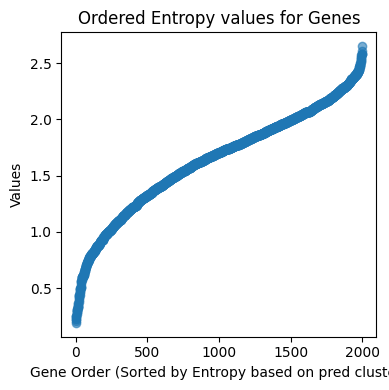

In [11]:
prior_manager = PriorInferenceManager(result_adata, df, RESULT_PATH, seed=cfg.seed)
prior_manager.task1_define_fine_clusters(method=cfg.fine_method, target_size=cfg.target_size)
prior_manager.task2_filter_genes(based_on="expert", keep_ngene=1000, use_filter=cfg.use_filter)
prior_manager.task3_calc_convexity(based_on=cfg.direction_base)

result_adata, df_updated, fine_clus_vec_np = prior_manager.finalize_for_training()
print("Prior inference completed.")

## Velocity Dataset

Subset to velocity genes and rebuild the data objects required for the second training stage.


In [12]:
prior_adata = result_adata.copy()

raw_adata = sc.read_h5ad(INPUT_FILE)
raw_adata = steer.prepare_spatial_adata(
    raw_adata,
    obs_copy_map={"celltype": "celltype1"},
    na_clear_keys=["subregion"],
    celltype_key="celltype",
    remove_celltypes=[],
)

scv.pp.filter_and_normalize(
    raw_adata,
    min_shared_counts=20,
    n_top_genes=2000,
)

assert all(prior_adata.obs_names == raw_adata.obs_names), "Observation names are not aligned!"
assert all(prior_adata.var_names == raw_adata.var_names), "Variable names are not aligned!"

raw_adata.layers["pred_cell_type"] = prior_adata.layers["pred_cell_type"]
raw_adata.obsm["X_pre_embed"] = prior_adata.obsm["X_pre_embed"]
raw_adata.obs["pred_cluster"] = prior_adata.obs["pred_cluster"].astype(int)

velo_adata = raw_adata[:, prior_adata.var["is_velocity_gene"]].copy()

df_fine, adjacency_matrix_fine, velo_adata = steer.preprocess_anndata_spatial(
    velo_adata,
    npc=30,
    NUM_AD_NEIGH=30,
    spatial_neighbors=cfg.spatial_neighbors,
    SMOOTH_NEIGH=cfg.smooth_neigh,
    moments_adj=True,
    neighbor_metric=cfg.neighbor_metric,
    combine_mode=cfg.graph,
    spatial_key="X_spatial",
    use_us=cfg.use_us,
)

dataset_fine = steer.preload_datasets_all_genes_anndata(
    df=df_fine,
    MODEL_MODE="whole",
    adata=velo_adata,
)
pyg_data_fine = steer.create_pyg_data(dataset_fine, adjacency_matrix_fine, normalize=True)
pyg_data_fine.fine_clus_vec = torch.tensor(fine_clus_vec_np, dtype=torch.long, device=device)

print(velo_adata)
print("Velocity-gene subset shape:", velo_adata.shape)


Filtered out 12279 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


/nvme/users/liuzhy/miniconda3/envs/steer_dev/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
AnnData object with n_obs × n_vars = 13258 × 1000
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subregion', 'interface', 'celltype1', 'subclusters_5_last', 'subregion5', 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'pred_cluster'
    var: 'n_cells_by_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'log1p', 'neighbors'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_spatial', 'X_pre_embed', 'X_pca_combined', 'X_pca_moments'
    layers: 'ambiguous', 'counts', 'matrix', 'spliced', 'unspliced', 'pred_cell_type', 'Ms', 'Mu', 'scale_Mu', 'scale_Ms'
    obsp: 'distances', 'connectivities'
Velocity-gene subset shape: (13258, 1000)


## Kinetic Learning

Run the main kinetic-learning stage using the prior inferred above.

- `full` mode: preserve the behavior of your original run by not passing extra training-control arguments and therefore using STEER defaults
- `fast` mode: use a lightweight quickstart-style configuration, including `expert_mode="slim"`, shorter pretraining/clustering, `velo_batch_size=512`, and more aggressive early stopping


In [13]:
stage2_kwargs = dict(
    device=device,
    device2=device,
    pyg_data=pyg_data_fine,
    MODEL_MODE="whole",
    adata=velo_adata,
    NUM_LOSS_NEIGH=30,
    max_n_cluster=cfg.expert,
    corr_mode=cfg.corr_mode,
    path=RESULT_PATH,
)
stage2_kwargs.update(
    get_stage2_training_overrides(
        cfg.training_mode,
        getattr(cfg, "finetune_epochs", None),
    )
)

velo_adata = steer.model_training_share_neighbor_adata(**stage2_kwargs)

print("Kinetic-learning stage completed.")


Using Fine Cluster Vector for Correlation Loss.
Epoch 0, Loss 0.2589128911495209
Epoch 50, Loss 0.16269493103027344
Epoch 100, Loss 0.14793340861797333
Epoch 150, Loss 0.1351746916770935
Epoch 200, Loss 0.12515060603618622
Epoch 250, Loss 0.11659395694732666
Epoch 300, Loss 0.10895542055368423
Epoch 350, Loss 0.10202070325613022
Epoch 400, Loss 0.09567110985517502
Epoch 450, Loss 0.09001993387937546
Epoch 500, Loss 0.0846339762210846
Epoch 550, Loss 0.07984798401594162
Epoch 600, Loss 0.07547919452190399
Epoch 650, Loss 0.07120946794748306
Epoch 700, Loss 0.06731133162975311
Epoch 750, Loss 0.06387172639369965
Epoch 800, Loss 0.06048090383410454
Epoch 850, Loss 0.05737226456403732
Epoch 900, Loss 0.055343613028526306
Epoch 950, Loss 0.05166403204202652
Epoch 1000, Loss 0.04917184263467789
Epoch 1050, Loss 0.04679033160209656
Epoch 1100, Loss 0.044529758393764496
Epoch 1150, Loss 0.04279634356498718
Epoch 1200, Loss 0.04079746827483177
Epoch 1250, Loss 0.039058245718479156
Epoch 1300, L

## Spatial Velocity Plot

Build the velocity graph and inspect the learned flow field in spatial coordinates.


In [14]:
result_adata = velo_adata.copy()

sc.pp.neighbors(result_adata, use_rep="X_refine_embed_t", n_neighbors=30)
steer.velocity_graph(result_adata, vkey="pred_vs_norm", xkey="model_Ms")

print("obs columns:")
print(sorted(result_adata.obs.columns.tolist()))

print("\nobsm keys:")
print(sorted(result_adata.obsm.keys()))

print("\nlayers:")
print(sorted(result_adata.layers.keys()))


computing velocity graph (using 1/128 cores)


  0%|          | 0/13258 [00:00<?, ?cells/s]

    finished (0:00:15) --> added 
    'pred_vs_norm_graph', sparse matrix with cosine correlations (adata.uns)
obs columns:
['Expert', 'Expert Weight', 'Pred Time', 'celltype', 'celltype1', 'initial_size', 'initial_size_spliced', 'initial_size_unspliced', 'interface', 'n_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pred_vs_norm_self_transition', 'pretrain_cluster', 'sample', 'subclusters_5_last', 'subregion', 'subregion5', 'total_counts', 'total_counts_mt', 'x', 'y']

obsm keys:
['X_alpha', 'X_beta', 'X_gamma', 'X_para', 'X_para_t', 'X_pca', 'X_pca_combined', 'X_pca_moments', 'X_pre_embed', 'X_refine_embed', 'X_refine_embed_t', 'X_spatial', 'X_umap', 'cluster_matrix', 'spatial']

layers:
['counts', 'final_recon_s', 'final_recon_u', 'init_regulate_state', 'model_Ms', 'model_Mu', 'orig_s', 'orig_u', 'pred_time_layer', 'pred_vs', 'pred_vs_norm', 'pred_vu', 'pred_vu_norm', 'recon_alpha', 'recon_alpha_norm', 'recon_beta', 'recon_gamma', 'recon_gamma_norm', 'regulate_state', 'scale_Ms', '

In [15]:
result_adata

AnnData object with n_obs × n_vars = 13258 × 1000
    obs: 'x', 'y', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'subregion', 'interface', 'celltype1', 'subclusters_5_last', 'subregion5', 'celltype', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'pretrain_cluster', 'Expert', 'Expert Weight', 'Pred Time', 'pred_vs_norm_self_transition'
    var: 'n_cells_by_counts', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'log1p', 'neighbors', 'pred_vs_norm_graph', 'pred_vs_norm_graph_neg', 'pred_vs_norm_params'
    obsm: 'X_pca', 'X_umap', 'spatial', 'X_spatial', 'X_pre_embed', 'X_pca_combined', 'X_pca_moments', 'X_refine_embed', 'cluster_matrix', 'X_alpha', 'X_beta', 'X_gamma', 'X_para', 'X_para_t', 'X_refine_embed_t'
    layers: 'counts', 'scale_Mu', 'scale_Ms', 'recon_alpha', 'recon_beta', 'recon_gamma', 'pred_vu', 'pred_vs', 'pred_vu_norm', 'pred_vs_norm', 'init_regulate_state', '

computing velocity embedding
    finished (0:00:01) --> added
    'pred_vs_norm_spatial', embedded velocity vectors (adata.obsm)
saving figure to file ./results/E8.5_S1.MPSTA_quickstart/scvelo_velo_joint_spatial_part.png


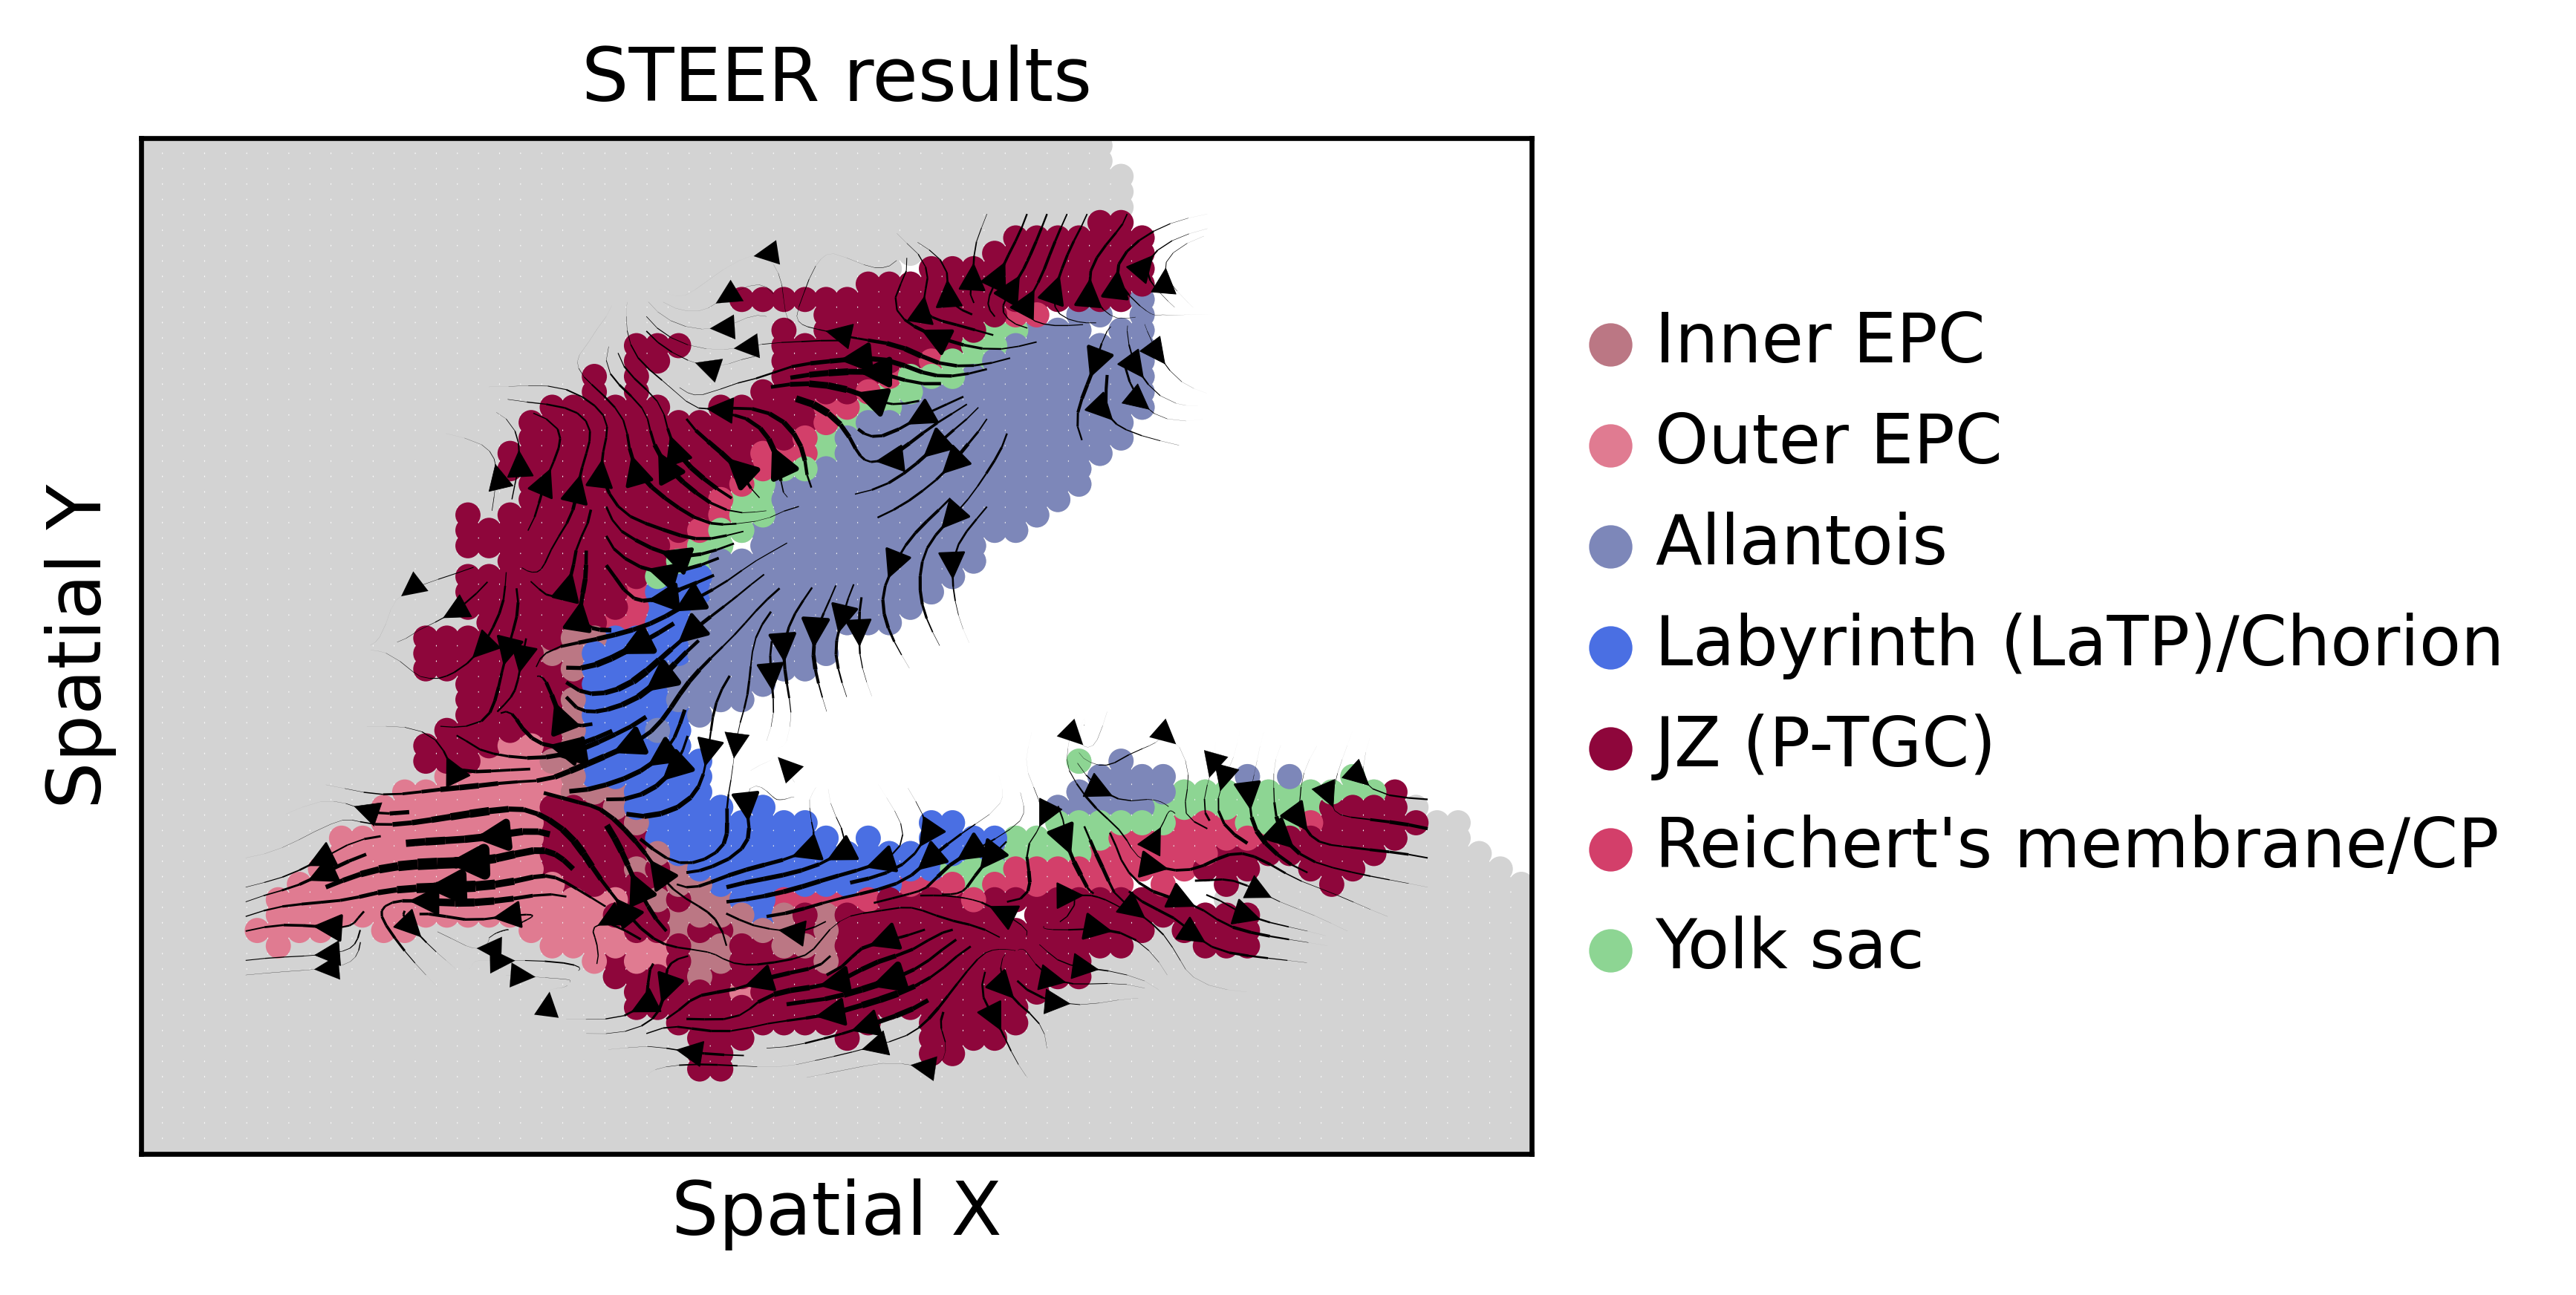

In [16]:
scv.settings.figdir = RESULT_PATH
scv.set_figure_params(style="scvelo", dpi=150, figsize=(5, 4), transparent=True)
if "X_spatial" not in result_adata.obsm and "spatial" in result_adata.obsm:
    result_adata.obsm["X_spatial"] = result_adata.obsm["spatial"].astype(float)
elif "X_spatial" in result_adata.obsm:
    result_adata.obsm["X_spatial"] = result_adata.obsm["X_spatial"].astype(float)
# scv.pl.velocity_embedding_stream(
#     result_adata,
#     basis="spatial",
#     vkey="pred_vs_norm",
#     color=["Expert", "Pred Time","subregion","celltype"],
#     title=["Expert Assignment", "Latent Time","subregion","celltype"],
#     show=True,
# )
scv.pl.velocity_embedding_stream(result_adata,color='subregion',size=66,smooth=0.8,vkey="pred_vs_norm",
                                 alpha=1,groups=['Inner EPC','Outer EPC','Allantois','Labyrinth (LaTP)/Chorion','JZ (P-TGC)',"Reichert's membrane/CP",'Yolk sac'],
                                 legend_loc='right',basis='spatial',add_margin=0.1,xlabel= 'Spatial X',ylabel='Spatial Y',figsize=(4,3), frameon=True, dpi=300,
                                 title='STEER results',save='velo_joint_spatial_part.png')